v8

**Changes from v7:**
1. **Physical loss normalisation** — empirical normalisation (divide by initial random-network loss) deleted. Each loss component is now divided by a fixed physical scale computed once from measured data and known beam parameters. Loss values are interpretable: `data = 0.1` means 10% of measured signal energy unexplained.
2. **Random Fourier features on ω** (Tancik et al. 2020) — breaks the spectral bias of the tanh MLP so sub-Hz-wide resonance peaks become learnable. `x` input stays raw (W is smooth in x).
3. **Curriculum learning by frequency** — replaces v7's data-only warmup. Training points are masked to low frequencies first, expanding in 4 stages. All three loss terms (PDE, BC, data) active from epoch 0.

**Additions beyond the planned three fixes (flagged, revertible):**
- WNet output scaled by `W_OUT_SCALE` (max displacement amplitude from data) so the network learns O(1) quantities instead of O(1e-7) metres.
- PDE normalisation is per collocation point, `ρA·(ω₀² + ω²)·W_scale`, not a constant ω₀-only scale — a constant scale would let high-frequency residuals dominate by (ω_max/ω₀)² ≈ 1e5 and reproduce the W≈0 collapse. The `/I` in the planning doc was a unit slip and is dropped (the residual already carries I).

## 1. Imports and device setup


In [ ]:
import os, io, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

import torch
import torch.nn as nn

# float64 is mandatory: we compute 4th-order spatial derivatives via autograd.
# float32 accumulates too much rounding error at each grad() call.
DTYPE  = torch.float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, " | dtype:", DTYPE)

from google.colab import files
torch.manual_seed(42)
np.random.seed(42)

# ── Checkpoint setup ─────────────────────────────────────────────────────────
# Saves training state to Google Drive so that if Colab disconnects mid-training,
# you can rerun the notebook and it picks up from the last checkpoint automatically.
from google.colab import drive
drive.mount('/content/drive')

CHECKPOINT_DIR = "/content/drive/MyDrive/pinn_v8_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CKPT_ADAM  = os.path.join(CHECKPOINT_DIR, "adam_checkpoint.pt")
CKPT_LBFGS = os.path.join(CHECKPOINT_DIR, "lbfgs_checkpoint.pt")
CKPT_DONE  = os.path.join(CHECKPOINT_DIR, "training_complete.pt")

# How often to save (every N epochs/steps).
# Each save takes ~1-2s, so 1000 epochs = ~20 saves over 20k epochs — negligible overhead.
ADAM_CKPT_EVERY  = 1000
LBFGS_CKPT_EVERY = 30


def save_adam_checkpoint(epoch, w_net, e_net, physical_params, optimizer, scheduler, history):
    """Save full Adam training state to Drive."""
    torch.save({
        "epoch":       epoch,
        "w_net":       w_net.state_dict(),
        "e_net":       e_net.state_dict(),
        "phys":        {k: v.detach().clone() for k, v in physical_params.items()},
        "optimizer":   optimizer.state_dict(),
        "scheduler":   scheduler.state_dict(),
        "history":     history,
    }, CKPT_ADAM)


def load_adam_checkpoint(w_net, e_net, physical_params, optimizer, scheduler):
    """Resume Adam from checkpoint. Returns (start_epoch, history) or (0, fresh_history)."""
    if not os.path.exists(CKPT_ADAM):
        return 0, None
    ckpt = torch.load(CKPT_ADAM, map_location=device, weights_only=False)
    w_net.load_state_dict(ckpt["w_net"])
    e_net.load_state_dict(ckpt["e_net"])
    for k, v in ckpt["phys"].items():
        physical_params[k].data.copy_(v)
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    start = ckpt["epoch"] + 1
    print(f"\u2713 Resumed Adam from epoch {start}")
    return start, ckpt["history"]


def save_lbfgs_checkpoint(step, w_net, e_net, physical_params, opt_lbfgs):
    """Save L-BFGS state to Drive."""
    torch.save({
        "step":  step,
        "w_net": w_net.state_dict(),
        "e_net": e_net.state_dict(),
        "phys":  {k: v.detach().clone() for k, v in physical_params.items()},
        "optimizer": opt_lbfgs.state_dict(),
    }, CKPT_LBFGS)


def load_lbfgs_checkpoint(w_net, e_net, physical_params, opt_lbfgs):
    """Resume L-BFGS from checkpoint. Returns start_step or 0."""
    if not os.path.exists(CKPT_LBFGS):
        return 0
    ckpt = torch.load(CKPT_LBFGS, map_location=device, weights_only=False)
    w_net.load_state_dict(ckpt["w_net"])
    e_net.load_state_dict(ckpt["e_net"])
    for k, v in ckpt["phys"].items():
        physical_params[k].data.copy_(v)
    opt_lbfgs.load_state_dict(ckpt["optimizer"])
    start = ckpt["step"] + 1
    print(f"\u2713 Resumed L-BFGS from step {start}")
    return start

Device: cuda  | dtype: torch.float64
Mounted at /content/drive


## 2. Beam geometry and experiment settings

**Boundary conditions agreed with supervisor:**
- `x = 0` → **fixed / clamped** end (with spring compliance kx, kphi to model imperfect clamping)
- `x = L` → **free** end with known tip mass `m_tip` and unknown tip force `F`

**What each unknown means:**
- `E(x)` — spatially varying Young's modulus [Pa]. Varies along beam length, e.g. due to non-uniform material or damage.
- `eta` — loss factor (hysteretic damping). Enters as complex modulus E*(x) = E(x)(1 + j·eta). Controls peak sharpness in FRF.
- `kx` — translational spring stiffness at clamped end [N/m]. Models fixture compliance in lateral direction. kx→∞ = perfect rigid clamp.
- `kphi` — rotational spring stiffness at clamped end [N·m/rad]. Models fixture compliance in rotation. kphi→∞ = perfect rigid clamp.
- `F` — unknown tip force amplitude [N]. The velocity of excitation is known but the actual force at the tip is not.


In [ ]:
# ── Beam geometry (fixed, known from measurement) ────────────────────────────
L          = 126.06e-3   # beam length [m]
width      = 10.13e-3    # width [m]
height     = 0.95e-3     # thickness [m]
rho        = 8216.0      # density [kg/m^3]
bending_axis = "weak"
x_meas     = L           # FRF measured at tip (free end)
m_tip      = 10e-3       # tip mass [kg]

# ── Frequency range ───────────────────────────────────────────────────────────
# Only keep data where Euler-Bernoulli is valid and SNR is good.
# From your experimental plot: useful signal up to ~5000 Hz.
MIN_FREQ_HZ = 1.0        # avoid singular matrix at 0 Hz
MAX_FREQ_HZ = 5000.0     # hard cutoff

# ── Initial guesses for scalar unknowns ──────────────────────────────────────
# Adjust E0_init to your beam material:
#   Steel     ~ 200e9 Pa
#   Aluminium ~  70e9 Pa
#   Brass     ~ 100e9 Pa
E0_init    = 200e9       # [Pa]  initial guess for E(x) mean level
eta_init   = 0.01        # [-]   loss factor
kx_init    = 1e5         # [N/m] translational spring at x=0
kphi_init  = 1e3         # [N·m/rad] rotational spring at x=0
F_init     = 0.1         # [N]   tip force amplitude

# ── Derived geometry ──────────────────────────────────────────────────────────
A = width * height
if bending_axis.lower() == "weak":
    I = width * height**3 / 12.0
else:
    I = height * width**3  / 12.0

plot_in_db = True
eps_db     = 1e-16

print(f"L={L:.4f} m  width={width:.5f} m  height={height:.5f} m")
print(f"A={A:.4e} m^2   I={I:.4e} m^4")
print(f"Frequency range: {MIN_FREQ_HZ} – {MAX_FREQ_HZ} Hz")


L=0.1261 m  width=0.01013 m  height=0.00095 m
A=9.6235e-06 m^2   I=7.2377e-13 m^4
Frequency range: 1.0 – 5000.0 Hz


## 3. Upload and load experimental FRF

Upload your `.npy` or `.npz` file. The loader handles common key naming conventions,
removes invalid entries, and sorts by frequency.


In [ ]:
def _pick(d, keys):
    for k in keys:
        if k in d: return k
    return None

def load_frf(path, x_meas):
    ext  = os.path.splitext(path)[1].lower()
    fk   = ["freq","f","frequency","f_hz","freq_s1"]
    vrfk = ["frf","V","velocity","response","H","s1_fft"]

    if ext == ".npz":
        data = np.load(path, allow_pickle=True)
        print("NPZ keys:", list(data.keys()))
        fkey = _pick(data, fk); vkey = _pick(data, vrfk)
        if fkey and vkey:
            f = data[fkey].reshape(-1).astype(float)
            V = data[vkey].reshape(-1)
        else:
            raise ValueError(f"Cannot find freq/FRF keys in {list(data.keys())}")

    elif ext == ".npy":
        arr  = np.load(path, allow_pickle=True)
        data = arr.item() if hasattr(arr, "item") else None
        if not isinstance(data, dict):
            raise ValueError("Plain .npy unsupported — use .npz")
        print("NPY keys:", list(data.keys()))
        fkey = _pick(data, fk); vkey = _pick(data, vrfk)
        if fkey and vkey:
            f = data[fkey].reshape(-1).astype(float)
            V = data[vkey].reshape(-1)
        else:
            raise ValueError(f"Cannot find freq/FRF keys in {list(data.keys())}")
    else:
        raise ValueError("Only .npy / .npz supported")

    if not np.iscomplexobj(V):
        raise ValueError("FRF array must be complex (real + imag parts)")

    # Clean up
    mask = np.isfinite(f) & np.isfinite(V.real) & np.isfinite(V.imag) & (f >= 0)
    f, V = f[mask], V[mask]
    order = np.argsort(f)
    f, V  = f[order], V[order]

    # Average duplicate frequencies
    df = pd.DataFrame({"f":f,"Vr":V.real,"Vi":V.imag}).groupby("f",as_index=False).mean()
    f  = df["f"].to_numpy()
    V  = df["Vr"].to_numpy() + 1j*df["Vi"].to_numpy()
    x  = np.full_like(f, x_meas)
    return f, x, V

uploaded      = files.upload()
uploaded_name = list(uploaded.keys())[0]
print("Uploaded:", uploaded_name)


Saving Output.npy to Output.npy
Uploaded: Output.npy


## 3.1 code to view the values in the `.npy` file

In [ ]:
# ── Inspect the uploaded file ─────────────────────────────────────────────────
ext = os.path.splitext(uploaded_name)[1].lower()
print(f"File: {uploaded_name}  ({ext})")

if ext == ".npz":
    raw = np.load(uploaded_name, allow_pickle=True)
    print(f"NPZ keys: {list(raw.keys())}")
    data_dict = {k: raw[k] for k in raw.keys()}
elif ext == ".npy":
    arr = np.load(uploaded_name, allow_pickle=True)
    if hasattr(arr, "item") and arr.dtype == object:
        data_dict = arr.item()
        print(f"NPY (dict) keys: {list(data_dict.keys())}")
    else:
        data_dict = {"array": arr}
        print(f"NPY (plain array), shape={arr.shape}")
else:
    raise ValueError(f"Unsupported extension: {ext}")

# Per-key summary
print("\n── Per-key summary ──")
for k, v in data_dict.items():
    arr = np.asarray(v)
    print(f"  {k:<20} shape={str(arr.shape):<15} dtype={str(arr.dtype):<15} "
          f"complex={np.iscomplexobj(arr)}")

# Pick frequency and FRF arrays using the same heuristic load_frf uses
fk_candidates = ["freq", "f", "frequency", "f_hz", "freq_s1"]
vk_candidates = ["frf", "V", "velocity", "response", "H", "s1_fft"]

f_key = next((k for k in fk_candidates if k in data_dict), None)
v_key = next((k for k in vk_candidates if k in data_dict), None)
print(f"\nFrequency key picked: {f_key}")
print(f"FRF key picked      : {v_key}")

f_arr = np.asarray(data_dict[f_key]).reshape(-1).astype(float)
V_arr = np.asarray(data_dict[v_key]).reshape(-1)

# ── Numerical preview ─────────────────────────────────────────────────────────
N = len(f_arr)
print(f"\nTotal points: {N}")
print(f"Frequency range: {f_arr.min():.3f} – {f_arr.max():.3f} Hz")
print(f"Frequency spacing (median): {np.median(np.diff(f_arr)):.4f} Hz")
print(f"FRF dtype: {V_arr.dtype}  (complex: {np.iscomplexobj(V_arr)})")

# Show first 5, middle 5, last 5 rows — enough to verify structure without spamming
def preview_block(label, sl):
    print(f"\n{label}")
    print(f"{'idx':>6} {'freq [Hz]':>12} {'Re(V)':>14} {'Im(V)':>14} "
          f"{'|V|':>12} {'|V| [dB]':>10}")
    for i in sl:
        v = V_arr[i]
        mag = abs(v)
        db = 20 * np.log10(mag + 1e-30)
        print(f"{i:>6} {f_arr[i]:>12.3f} {v.real:>14.4e} {v.imag:>14.4e} "
              f"{mag:>12.4e} {db:>10.2f}")

preview_block("First 5 rows:", range(5))
preview_block("Middle 5 rows:", range(N//2 - 2, N//2 + 3))
preview_block("Last 5 rows:", range(N - 5, N))

File: Output.npy  (.npy)
NPY (dict) keys: ['t', 's1_t', 'freq_s1', 's1_fft']

── Per-key summary ──
  t                    shape=(192000,)       dtype=float64         complex=False
  s1_t                 shape=(192000,)       dtype=float64         complex=False
  freq_s1              shape=(96000,)        dtype=float64         complex=False
  s1_fft               shape=(96000,)        dtype=complex128      complex=True

Frequency key picked: freq_s1
FRF key picked      : s1_fft

Total points: 96000
Frequency range: 0.000 – 23999.750 Hz
Frequency spacing (median): 0.2500 Hz
FRF dtype: complex128  (complex: True)

First 5 rows:
   idx    freq [Hz]          Re(V)          Im(V)          |V|   |V| [dB]
     0        0.000     6.1957e-06     0.0000e+00   6.1957e-06    -104.16
     1        0.250     2.7522e-06    -2.4124e-05   2.4280e-05     -92.29
     2        0.500    -2.4234e-05    -1.8950e-05   3.0763e-05     -90.24
     3        0.750     1.8150e-05    -8.8563e-05   9.0404e-05     -80

## 3.1.b visualization
visualise the frf given by the `.npy` file


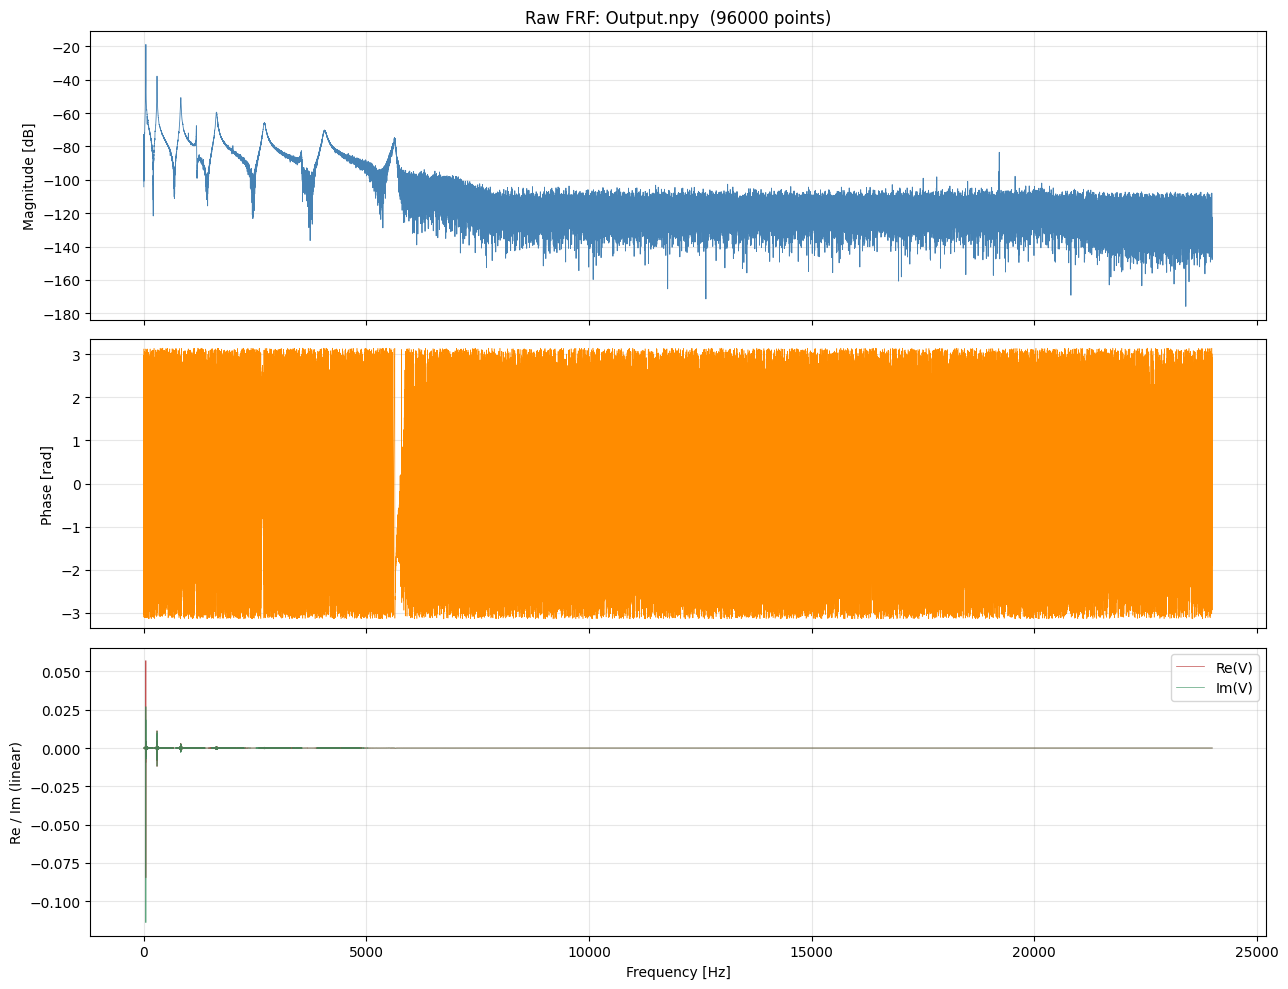

Peak |V|       : 1.146e-01  at 46.00 Hz
Median |V|     : 1.609e-06
Min |V|        : 1.606e-09  at 23404.50 Hz
Dynamic range  : 157.1 dB


In [ ]:
# ── Visualise raw FRF: magnitude (dB) and phase (rad) ─────────────────────────
mag = np.abs(V_arr)
phase = np.angle(V_arr)

fig, axs = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# Magnitude in dB — standard FRF view
axs[0].plot(f_arr, 20*np.log10(mag + 1e-30), lw=0.6, color="steelblue")
axs[0].set_ylabel("Magnitude [dB]")
axs[0].set_title(f"Raw FRF: {uploaded_name}  ({N} points)")
axs[0].grid(alpha=0.3)

# Phase (wrapped, raw — this is what you'd actually feed to atan2)
axs[1].plot(f_arr, phase, lw=0.4, color="darkorange")
axs[1].set_ylabel("Phase [rad]")
axs[1].set_ylim(-np.pi - 0.2, np.pi + 0.2)
axs[1].grid(alpha=0.3)

# Real and imaginary parts on linear scale — useful for seeing what the
# PINN data loss actually compares against
axs[2].plot(f_arr, V_arr.real, lw=0.5, label="Re(V)", color="firebrick", alpha=0.8)
axs[2].plot(f_arr, V_arr.imag, lw=0.5, label="Im(V)", color="seagreen",  alpha=0.8)
axs[2].set_ylabel("Re / Im (linear)")
axs[2].set_xlabel("Frequency [Hz]")
axs[2].legend(loc="upper right")
axs[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Quick stats for context
print(f"Peak |V|       : {mag.max():.3e}  at {f_arr[np.argmax(mag)]:.2f} Hz")
print(f"Median |V|     : {np.median(mag):.3e}")
print(f"Min |V|        : {mag.min():.3e}  at {f_arr[np.argmin(mag)]:.2f} Hz")
print(f"Dynamic range  : {20*np.log10(mag.max()/mag.min()):.1f} dB")

## 4. Filter, smooth and subsample the experimental FRF

**Why cut at 5000 Hz?**
Euler-Bernoulli beam theory is only valid for the first few bending modes.
Beyond ~5 kHz for this geometry, the model is inaccurate and the data is noise-dominated.
Training on that region harms parameter identification.

**Why smooth?**
The PINN's physics loss enforces a smooth analytical solution.
Raw experimental noise conflicts with this — the optimizer chases noise instead of physics,
and identified parameters (E(x), eta, etc.) never converge.
Savitzky-Golay preserves resonance peak positions and shapes while removing the noise floor.


NPY keys: ['t', 's1_t', 'freq_s1', 's1_fft']
After cutoff: 19997 points  (1.0 – 5000.0 Hz, df=0.250 Hz)
Detected 6 peaks at: [45.8, 296.5, 830.5, 1633.0, 2708.0, 4061.2] Hz
Estimated FWHMs (Hz): [42.45, 150.73, 301.29, 451.71, 641.44, 334.57]
Detected 5 anti-resonances at: [210.5, 682.0, 1415.8, 2452.2, 3741.5] Hz
Band half-widths (Hz): [80.0, 80.0, 80.0, 80.0, 80.0, 80.0]
Training points: 377


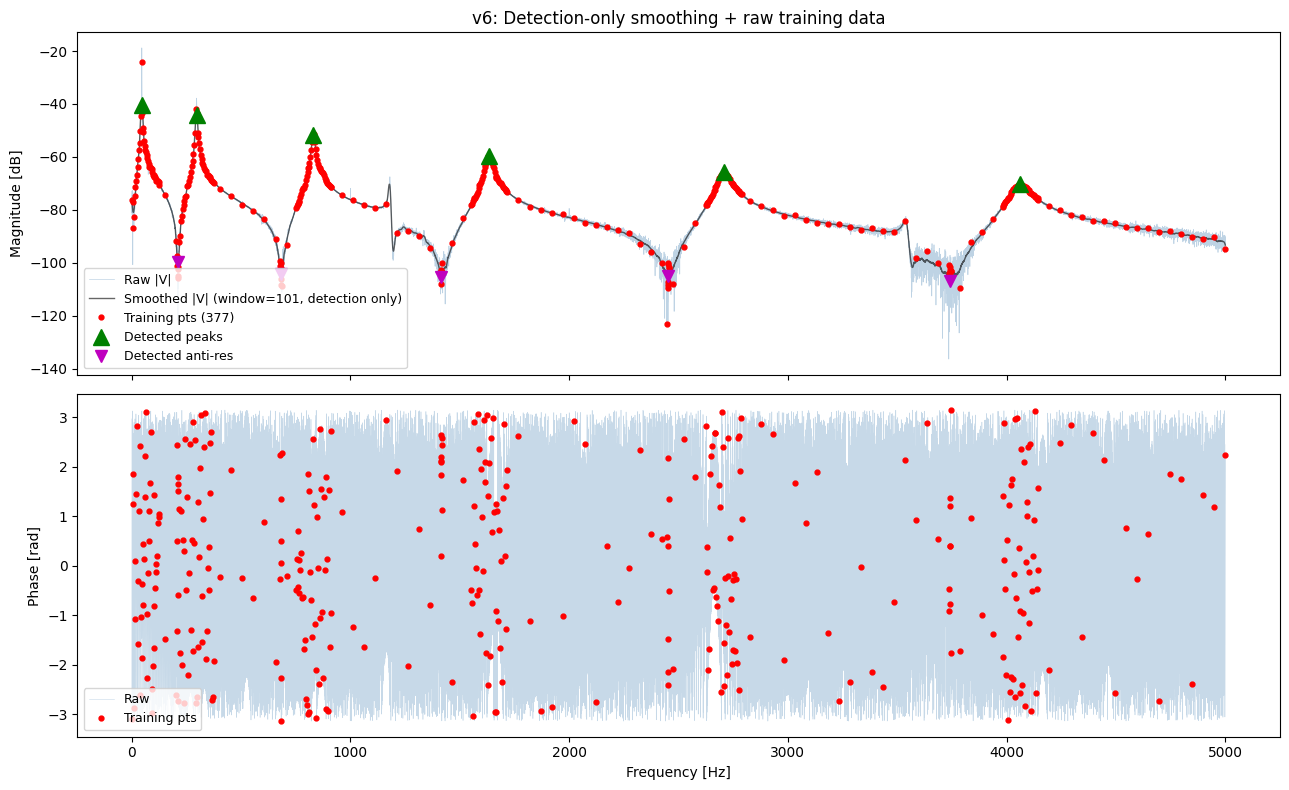


>> CHECK: Red dots should sit on the RAW peak tops (blue), not the black smoothed line.
>>        Peak count should be 5–9.
>>        Total training points should be 400–700.


In [ ]:
from scipy.signal import find_peaks, peak_widths

f_raw, x_raw, V_raw = load_frf(uploaded_name, x_meas=x_meas)

# ── Hard frequency cutoff (5500 Hz to capture all 7 visible modes) ────────────
mask = (f_raw >= MIN_FREQ_HZ) & (f_raw <= MAX_FREQ_HZ)
f_cut, V_cut = f_raw[mask], V_raw[mask]
df_raw = f_cut[1] - f_cut[0]
print(f"After cutoff: {len(f_cut)} points  ({f_cut.min():.1f} – {f_cut.max():.1f} Hz, df={df_raw:.3f} Hz)")

# ── Peak detection: smooth |V| in dB heavily, find peaks with high prominence ─
# This signal is used ONLY for finding peak locations and widths, never for training.
mag_db_raw = 20 * np.log10(np.abs(V_cut) + eps_db)

DET_WIN = 101                                  # 25 Hz of smoothing for detection
mag_db_detect = savgol_filter(mag_db_raw, window_length=DET_WIN, polyorder=3)

PEAK_PROMINENCE = 20.0                          # 20 dB — well above noise wiggles
PEAK_DISTANCE   = 200                           # min separation 50 Hz between peaks

peak_idx, _ = find_peaks(mag_db_detect, prominence=PEAK_PROMINENCE, distance=PEAK_DISTANCE)
peak_freqs  = f_cut[peak_idx]
print(f"Detected {len(peak_idx)} peaks at: {np.round(peak_freqs, 1).tolist()} Hz")

if len(peak_idx) > 12 or len(peak_idx) < 5:
    print(f"WARNING: {len(peak_idx)} peaks — adjust PEAK_PROMINENCE.")

widths_samples, _, _, _ = peak_widths(mag_db_detect, peak_idx, rel_height=0.5)
peak_fwhm_hz = widths_samples * df_raw
print(f"Estimated FWHMs (Hz): {np.round(peak_fwhm_hz, 2).tolist()}")

antires_idx, _ = find_peaks(-mag_db_detect, prominence=PEAK_PROMINENCE, distance=PEAK_DISTANCE)
antires_freqs = f_cut[antires_idx]
print(f"Detected {len(antires_idx)} anti-resonances at: {np.round(antires_freqs, 1).tolist()} Hz")

# ── Training data: NO smoothing ──────────────────────────────────────────────
# Peaks are too narrow to survive smoothing; we trust the raw V values and
# rely on dense sampling around peaks to average out noise in the data loss.
V_for_training = V_cut

# ── Build peak-aware training set ────────────────────────────────────────────
PTS_PER_PEAK    = 40
PTS_PER_ANTIRES = 8
PTS_BACKGROUND  = 100
BAND_FWHMS      = 3.0   # half-width = 3 FWHMs of the (over-smoothed) peak

# Clip band widths so very narrow peaks get a minimum band and very wide
# peaks don't dominate the sampling budget
band_halfwidths = np.clip(BAND_FWHMS * peak_fwhm_hz, 5.0, 80.0)
print(f"Band half-widths (Hz): {np.round(band_halfwidths, 1).tolist()}")

f_train_list = []
for fp, hw in zip(peak_freqs, band_halfwidths):
    band_lo = max(fp - hw, f_cut[0])
    band_hi = min(fp + hw, f_cut[-1])
    f_train_list.append(np.linspace(band_lo, band_hi, PTS_PER_PEAK))

for fa in antires_freqs:
    band_lo = max(fa - 3.0, f_cut[0])
    band_hi = min(fa + 3.0, f_cut[-1])
    f_train_list.append(np.linspace(band_lo, band_hi, PTS_PER_ANTIRES))

f_train_list.append(np.linspace(f_cut[0], f_cut[-1], PTS_BACKGROUND))

# Merge, snap to raw frequencies, deduplicate
f_train_request = np.unique(np.concatenate(f_train_list))
snap_idx = np.searchsorted(f_cut, f_train_request)
snap_idx = np.clip(snap_idx, 0, len(f_cut) - 1)
left  = np.clip(snap_idx - 1, 0, len(f_cut) - 1)
choose_left = np.abs(f_cut[left] - f_train_request) < np.abs(f_cut[snap_idx] - f_train_request)
snap_idx = np.unique(np.where(choose_left, left, snap_idx))

f_train = f_cut[snap_idx]
V_train = V_for_training[snap_idx]
x_train = np.full_like(f_train, x_meas)
print(f"Training points: {len(f_train)}")

# ── Diagnostic plot ──────────────────────────────────────────────────────────
fig, axs = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axs[0].plot(f_cut, mag_db_raw, alpha=0.35, lw=0.5, color="steelblue", label="Raw |V|")
axs[0].plot(f_cut, mag_db_detect, "-", lw=1.0, color="black", alpha=0.6,
            label=f"Smoothed |V| (window={DET_WIN}, detection only)")
axs[0].plot(f_train, 20*np.log10(np.abs(V_train)+eps_db),
            "ro", ms=3.5, label=f"Training pts ({len(f_train)})")
axs[0].plot(peak_freqs, mag_db_detect[peak_idx], "g^", ms=11, label="Detected peaks")
axs[0].plot(antires_freqs, mag_db_detect[antires_idx], "mv", ms=8, label="Detected anti-res")
axs[0].set_ylabel("Magnitude [dB]"); axs[0].legend(loc="lower left", fontsize=9)
axs[0].set_title("v6: Detection-only smoothing + raw training data")

axs[1].plot(f_cut, np.angle(V_cut), alpha=0.3, color="steelblue", lw=0.4, label="Raw")
axs[1].plot(f_train, np.angle(V_train), "ro", ms=3.5, label="Training pts")
axs[1].set_ylabel("Phase [rad]"); axs[1].set_xlabel("Frequency [Hz]")
axs[1].legend(loc="lower left", fontsize=9)
plt.tight_layout(); plt.show()

print("\n>> CHECK: Red dots should sit on the RAW peak tops (blue), not the black smoothed line.")
print(">>        Peak count should be 5–9.")
print(">>        Total training points should be 400–700.")

## 5. Convert to tensors and define normalization

Neural networks train faster when inputs are scaled to [-1, 1].
Without normalization, ω spans ~6 to ~31,000 rad/s — the gradient signal
for low-frequency inputs would be negligible compared to high-frequency ones.


In [ ]:
omega_train  = 2.0 * np.pi * f_train

x_t     = torch.tensor(x_train,       dtype=DTYPE, device=device).view(-1,1)
omega_t = torch.tensor(omega_train,   dtype=DTYPE, device=device).view(-1,1)
Vr_t    = torch.tensor(V_train.real,  dtype=DTYPE, device=device).view(-1,1)
Vi_t    = torch.tensor(V_train.imag,  dtype=DTYPE, device=device).view(-1,1)

omega_min = float(omega_train.min())
omega_max = float(omega_train.max())

def norm_x(x):
    return 2.0 * x / L - 1.0                                   # [0,L]   -> [-1,1]

def norm_omega(w):
    return 2.0*(w - omega_min)/(omega_max - omega_min) - 1.0   # [wmin,wmax] -> [-1,1]

# ── v8: physical displacement scale ──────────────────────────────────────────
# Largest displacement amplitude implied by the measured velocity: |W| = |V|/ω.
# Used (a) to scale WNet's output so the net works with O(1) numbers, and
# (b) as the W_scale in the physical loss normalisation.
W_OUT_SCALE = float(torch.max(torch.sqrt(Vr_t**2 + Vi_t**2) / omega_t).item())

print(f"omega range: {omega_min:.1f} - {omega_max:.1f} rad/s")
print(f"W_OUT_SCALE = {W_OUT_SCALE:.3e} m   (max |V|/omega over training points)")


omega range: 6.3 - 31415.9 rad/s
W_OUT_SCALE = 2.130e-04 m   (max |V|/omega over training points)


## 6. Neural network architectures

**Two networks are trained simultaneously:**

`WNet` — displacement field network
- Input: (x, ω), Output: (W_real, W_imag)
- Represents the complex displacement solution at any spatial point and frequency.

`ENet` — spatially varying stiffness network
- Input: (x), Output: E(x) bounded in [E_MIN, E_MAX] via sigmoid (v4 change, kept)

**v8 CHANGE — Random Fourier features on ω (Fix 2):**
tanh MLPs have spectral bias: low-frequency functions are learned orders of
magnitude faster than high-frequency ones. The FRF's resonance peaks are sub-Hz
wide — high-frequency content in ω — so the v7 network found the smooth average
and never the peaks. We inject sinusoidal features
`[sin(2π·B·ω_norm), cos(2π·B·ω_norm)]` with `B ~ N(0, σ²)`, `σ = FOURIER_SIGMA`,
giving the network built-in oscillatory basis functions in ω.
- `x` stays raw: W(x) along the beam is smooth, no spectral bias problem there.
- `FOURIER_SIGMA = 10` → features with up to ~10 cycles across the normalized
  ω-range. Six peaks in the range, so comfortable margin. Raise to 20–30 if
  peaks still come out smoothed.
- `B_freq` is registered as a **buffer**: it is saved inside checkpoints and
  moves with `.to(device)`, so a reload can never silently use a different
  random projection.

**v8 CHANGE — output scaling:**
Physical displacements here are ~1e-7 m, but a freshly initialized MLP outputs
O(1). Forcing the net to shrink its output by 7 orders of magnitude is exactly
the "loss looks tiny but nothing is learned" dynamic from v7. WNet output is
multiplied by `W_OUT_SCALE` so the network itself learns O(1) quantities.

Both nets use **Tanh activations** — required because we compute up to 4th-order
spatial derivatives via autograd (ReLU has zero 2nd derivative a.e.).


In [ ]:
# ── E(x) bounds [Pa] ─────────────────────────────────────────────────────────
E_MIN = 50e9    # 50 GPa  — softest plausible metal
E_MAX = 400e9   # 400 GPa — hardest plausible metal/ceramic

# ── v8 Fix 2: random Fourier features on omega ───────────────────────────────
N_FOURIER     = 64
FOURIER_SIGMA = 10.0   # ~10 cycles across normalized omega-range


class WNet(nn.Module):
    """Displacement field: (x, omega) -> (W_real, W_imag).

    v8: omega input is Fourier-encoded to break spectral bias; output is
    scaled by W_OUT_SCALE so the network learns O(1) quantities.
    """
    def __init__(self, n_fourier=N_FOURIER, sigma=FOURIER_SIGMA):
        super().__init__()
        # Fixed random projection for Fourier features. Registered as a buffer:
        # saved in checkpoints, moved by .to(device), NOT trainable.
        gen = torch.Generator().manual_seed(42)
        B = torch.randn(n_fourier, 1, generator=gen, dtype=DTYPE) * sigma
        self.register_buffer("B_freq", B)

        in_dim = 1 + 2 * n_fourier   # raw x + [sin, cos] features of omega = 129
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.Tanh(),
            nn.Linear(128, 128),    nn.Tanh(),
            nn.Linear(128, 128),    nn.Tanh(),
            nn.Linear(128, 128),    nn.Tanh(),
            nn.Linear(128, 2),
        )

    def fourier_omega(self, omega_norm):
        proj = omega_norm @ self.B_freq.T * (2.0 * np.pi)      # (N, n_fourier)
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=1)

    def forward(self, x, omega):
        xn = norm_x(x)
        of = self.fourier_omega(norm_omega(omega))
        z  = torch.cat([xn, of], dim=1)
        out = self.net(z) * W_OUT_SCALE                        # physical metres
        return out[:, 0:1], out[:, 1:2]                        # Wr, Wi


class ENet(nn.Module):
    """
    Spatially varying Young's modulus: x -> E(x) in [E_MIN, E_MAX]
    (sigmoid bounding since v4 — unchanged in v8).
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1),
        )

        # Initialize last layer so sigmoid output ~= E0_init
        with torch.no_grad():
            target_sigmoid = (E0_init - E_MIN) / (E_MAX - E_MIN)
            init_bias = np.log(target_sigmoid / (1.0 - target_sigmoid))
            self.net[-1].bias.fill_(init_bias)
            self.net[-1].weight.fill_(0.0)

    def forward(self, x):
        xn  = norm_x(x)
        raw = self.net(xn)
        return E_MIN + (E_MAX - E_MIN) * torch.sigmoid(raw)


w_net = WNet().to(device).to(DTYPE)
e_net = ENet().to(device).to(DTYPE)

print("WNet params:", sum(p.numel() for p in w_net.parameters()))
print("ENet params:", sum(p.numel() for p in e_net.parameters()))
print("WNet input dim:", 1 + 2 * N_FOURIER)


WNet params: 66434
ENet params: 8513
WNet input dim: 129


## 7. Scalar trainable parameters

`eta`, `kx`, `kphi`, `F` are identified as scalar `nn.Parameter` objects.
All use softplus to enforce positivity.

Note: `E(x)` is now handled by ENet above, not a scalar.
The scalar parameters capture damping, boundary compliance, and excitation force.


In [ ]:
def inv_sp(y):
    y = np.float64(y)
    return float(np.where(y > 50, y, np.log(np.expm1(y))))

eta_scale  = 1.0
kx_scale   = 1e3      # N/m   — start soft, let optimizer find the right level
kphi_scale = 1e1      # N*m/rad
F_scale    = 1.0      # N

eta_raw  = nn.Parameter(torch.tensor([inv_sp(eta_init/eta_scale)],   dtype=DTYPE, device=device))
kx_raw   = nn.Parameter(torch.tensor([inv_sp(kx_init/kx_scale)],     dtype=DTYPE, device=device))
kphi_raw = nn.Parameter(torch.tensor([inv_sp(kphi_init/kphi_scale)], dtype=DTYPE, device=device))
F_raw    = nn.Parameter(torch.tensor([inv_sp(F_init/F_scale)],       dtype=DTYPE, device=device))

def get_params():
    sp = torch.nn.functional.softplus
    return (
        (sp(eta_raw)  + 1e-12) * eta_scale,
        (sp(kx_raw)   + 1e-12) * kx_scale,
        (sp(kphi_raw) + 1e-12) * kphi_scale,
        (sp(F_raw)    + 1e-12) * F_scale,
    )

# Scalar parameter LRs match the network LRs.
optimizer = torch.optim.Adam([
    {"params": list(w_net.parameters()),                           "lr": 1e-3},
    {"params": list(e_net.parameters()),                           "lr": 1e-3},
    {"params": [eta_raw, kx_raw, kphi_raw, F_raw],                "lr": 1e-3},
])

# Cosine annealing with warm restarts: smoother than ReduceLROnPlateau,
# no reaction to noisy loss signal.

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=4000, T_mult=2, eta_min=1e-6
)

print("eta_init :", eta_init)
print("kx_init  :", kx_init)
print("kphi_init:", kphi_init)
print("F_init   :", F_init)

eta_init : 0.01
kx_init  : 100000.0
kphi_init: 1000.0
F_init   : 0.1


## 8. Collocation points for PDE residual

Collocation points are (x, ω) locations where we evaluate the beam PDE.
They are **separate from the data points** — they enforce the physics equation
everywhere in the (x, ω) domain, not just where measurements exist.

`x_col` requires `requires_grad=True` because we differentiate W and E
up to 4th order with respect to x.


In [ ]:
Nx, Nw = 50, 50   # 2500 collocation points total

xc = torch.linspace(0.0, L, Nx, dtype=DTYPE, device=device)
wc = torch.linspace(omega_min, omega_max, Nw, dtype=DTYPE, device=device)

xx, ww    = torch.meshgrid(xc, wc, indexing="ij")
x_col     = xx.reshape(-1,1).clone().detach().requires_grad_(True)
omega_col = ww.reshape(-1,1).clone().detach()

print(f"Collocation grid: {Nx}×{Nw} = {x_col.shape[0]} points")


Collocation grid: 50×50 = 2500 points


## 9. Autograd derivative helper

`grad(y, x)` computes ∂y/∂x using PyTorch autograd.
We call this sequentially to get higher-order derivatives:
`W_x → W_xx → W_xxx → W_xxxx` and `E_x → E_xx`.

`create_graph=True` is essential — it keeps the computational graph alive
so that gradients of gradients can themselves be differentiated during backprop.


In [ ]:
def grad(y, x):
    return torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


## 10. Physics-informed loss function

### PDE for spatially varying E(x)

For constant E, the beam PDE is simply: `EI·W'''' - ρAω²W = 0`

For spatially varying E(x), the bending moment is `M = E(x)I·W''`, and the
PDE becomes (applying the product rule twice):

E(x)·W'''' + 2·E'(x)·W''' + E''(x)·W'' - (ρA/I)·ω²·W = 0

With complex modulus E*(x) = E(x)(1+jη), both real and imaginary parts give
separate residuals.

### Boundary conditions

**At x=0** (clamped with spring compliance):
- `E(0)I·W''(0) + kphi·W'(0) = 0` (rotational spring)
- `E(0)I·W'''(0) + kx·W(0) = 0` (translational spring)

**At x=L** (free end with tip mass and force):
- `E(L)I·W''(L) = 0` (zero moment)
- `E(L)I·W'''(L) + m_tip·ω²·W(L) + F = 0` (tip inertia + force)

### Data loss
Measured FRF is velocity: `V = jω·W`, so `V_real = -ω·W_imag`, `V_imag = +ω·W_real`.
We support two modes:
- **Linear**: `(V_pred - V_meas)²` — gives correct amplitudes
- **Log-magnitude**: `(log|V_pred| - log|V_meas|)²` — weights peaks and valleys
  equally across orders of magnitude

### Loss normalisation (v7)
The PDE residual is naturally O(10²⁰) because E ~ 10¹¹ Pa, while the data
loss is O(10⁻⁴). Without normalisation, the optimiser ignores the data and
fits only the physics — converging to a trivial smooth solution with no
resonances. We solve this by capturing the initial value of each loss
component in a single forward pass, then dividing each component by its
initial value during training. After normalisation, all three components
start at 1.0 and the weights `(w_pde, w_bc, w_data)` actually represent
priorities.

In [ ]:
A_t     = torch.tensor(A,     dtype=DTYPE, device=device)
I_t     = torch.tensor(I,     dtype=DTYPE, device=device)
rho_t   = torch.tensor(rho,   dtype=DTYPE, device=device)
m_tip_t = torch.tensor(m_tip, dtype=DTYPE, device=device)

# ── v8 Fix 1: fixed physical scales (computed ONCE, no network dependence) ───
# Data: mean-square of measurements — signal energy scale.
V_meas_scale_sq = float(torch.mean(Vr_t**2 + Vi_t**2).item()) + 1e-30

# Characteristic beam frequency: omega0^2 = E0*I / (rho*A*L^4).
# At omega0 the stiffness term I*E*W'''' and the inertia term rho*A*omega^2*W
# are the same size, so rho*A*(omega0^2 + omega^2)*W_scale tracks whichever
# term dominates at each collocation frequency.
omega0  = float(np.sqrt(E0_init * I / (rho * A * L**4)))
W_scale = W_OUT_SCALE

# BC residuals are forces [N] (moments get an extra factor L):
bc_force_scale = m_tip * omega_max**2 * W_scale

print(f"omega0          = {omega0:.2f} rad/s  ({omega0/2/np.pi:.2f} Hz)")
print(f"W_scale         = {W_scale:.3e} m")
print(f"V_meas_scale_sq = {V_meas_scale_sq:.3e} (m/s)^2")
print(f"bc_force_scale  = {bc_force_scale:.3e} N")


def pinn_loss(w_pde=1.0, w_bc=10.0, w_data=1.0, data_tensors=None):
    """v8 physics-informed loss with physical normalisation.

    data_tensors: optional (x_d, omega_d, Vr_d, Vi_d) tuple for curriculum
                  masking. None = full training set. The data loss is always
                  normalised by the FULL-set energy V_meas_scale_sq so its
                  value means the same thing in every curriculum stage.

    All returned components are dimensionless:
      data = 0.1  ->  10% of measured signal energy unexplained
      data = 1.0  ->  as bad as predicting V = 0 everywhere
    """
    eta, kx, kphi, F = get_params()

    # E(x) and its derivatives
    E_col  = e_net(x_col)
    E_x    = grad(E_col, x_col)
    E_xx   = grad(E_x,   x_col)

    # Displacement field and derivatives up to 4th order
    Wr, Wi   = w_net(x_col, omega_col)
    Wr_x     = grad(Wr,     x_col);  Wi_x    = grad(Wi,     x_col)
    Wr_xx    = grad(Wr_x,   x_col);  Wi_xx   = grad(Wi_x,   x_col)
    Wr_xxx   = grad(Wr_xx,  x_col);  Wi_xxx  = grad(Wi_xx,  x_col)
    Wr_xxxx  = grad(Wr_xxx, x_col);  Wi_xxxx = grad(Wi_xxx, x_col)

    omega2 = omega_col**2

    LWr = E_col*Wr_xxxx + 2*E_x*Wr_xxx + E_xx*Wr_xx
    LWi = E_col*Wi_xxxx + 2*E_x*Wi_xxx + E_xx*Wi_xx

    r_pde_r = I_t*(LWr - eta*LWi) - rho_t*A_t*omega2*Wr
    r_pde_i = I_t*(LWi + eta*LWr) - rho_t*A_t*omega2*Wi

    # Per-point physical scale: O(1) residuals at every frequency.
    # NOT a constant omega0-only scale — that would let high-frequency
    # residuals dominate by (omega_max/omega0)^2 ~ 1e5 and push W -> 0.
    pde_den  = rho_t * A_t * (omega0**2 + omega2) * W_scale
    pde_loss = torch.mean((r_pde_r/pde_den)**2 + (r_pde_i/pde_den)**2)

    # Boundary conditions
    omega_b = omega_col.detach()

    x0         = torch.zeros_like(omega_b, requires_grad=True)
    Wr0, Wi0   = w_net(x0, omega_b)
    E0_val     = e_net(x0)
    Wr0_x      = grad(Wr0,   x0);  Wi0_x   = grad(Wi0,   x0)
    Wr0_xx     = grad(Wr0_x, x0);  Wi0_xx  = grad(Wi0_x, x0)
    Wr0_xxx    = grad(Wr0_xx,x0);  Wi0_xxx = grad(Wi0_xx,x0)
    EI0_r = E0_val * I_t
    EI0_i = E0_val * I_t * eta
    bc0_rot_r = (EI0_r*Wr0_xx  - EI0_i*Wi0_xx)  + kphi*Wr0_x
    bc0_rot_i = (EI0_r*Wi0_xx  + EI0_i*Wr0_xx)  + kphi*Wi0_x
    bc0_tr_r  = (EI0_r*Wr0_xxx - EI0_i*Wi0_xxx) + kx*Wr0
    bc0_tr_i  = (EI0_r*Wi0_xxx + EI0_i*Wr0_xxx) + kx*Wi0

    xL         = torch.full_like(omega_b, L, requires_grad=True)
    WrL, WiL   = w_net(xL, omega_b)
    E_L_val    = e_net(xL)
    WrL_x      = grad(WrL,    xL); WiL_x   = grad(WiL,    xL)
    WrL_xx     = grad(WrL_x,  xL); WiL_xx  = grad(WiL_x,  xL)
    WrL_xxx    = grad(WrL_xx, xL); WiL_xxx = grad(WiL_xx, xL)
    EIL_r = E_L_val * I_t
    EIL_i = E_L_val * I_t * eta
    bcL_m_r = EIL_r*WrL_xx  - EIL_i*WiL_xx
    bcL_m_i = EIL_r*WiL_xx  + EIL_i*WrL_xx
    bcL_v_r = (EIL_r*WrL_xxx - EIL_i*WiL_xxx) + m_tip_t*omega_b**2*WrL + F
    bcL_v_i = (EIL_r*WiL_xxx + EIL_i*WrL_xxx) + m_tip_t*omega_b**2*WiL

    # Physical scales: forces / bc_force_scale, moments / (bc_force_scale*L)
    fS = bc_force_scale
    mS = bc_force_scale * L
    bc_loss = torch.mean(
        (bc0_rot_r/mS)**2 + (bc0_rot_i/mS)**2 +
        (bc0_tr_r /fS)**2 + (bc0_tr_i /fS)**2 +
        (bcL_m_r  /mS)**2 + (bcL_m_i  /mS)**2 +
        (bcL_v_r  /fS)**2 + (bcL_v_i  /fS)**2
    )

    # Data loss on (possibly curriculum-masked) training points
    if data_tensors is None:
        x_d, om_d, Vr_d, Vi_d = x_t, omega_t, Vr_t, Vi_t
    else:
        x_d, om_d, Vr_d, Vi_d = data_tensors

    Wr_d, Wi_d = w_net(x_d, om_d)
    Vp_r = -om_d * Wi_d
    Vp_i =  om_d * Wr_d
    data_loss = torch.mean((Vp_r - Vr_d)**2 + (Vp_i - Vi_d)**2) / V_meas_scale_sq

    total = w_pde*pde_loss + w_bc*bc_loss + w_data*data_loss
    return total, {
        "loss": total.item(),
        "pde":  pde_loss.item(),
        "bc":   bc_loss.item(),
        "data": data_loss.item(),   # 1.0 = predicting zero, 0 = perfect fit
        "eta":  eta.item(), "kx": kx.item(),
        "kphi": kphi.item(), "F": F.item(),
    }


omega0          = 85.15 rad/s  (13.55 Hz)
W_scale         = 2.130e-04 m
V_meas_scale_sq = 1.083e-05 (m/s)^2
bc_force_scale  = 2.102e+03 N


## 11. Training — Phase 1: Adam with frequency curriculum

**v8 Fix 3 — curriculum learning by frequency** (replaces v7's data-only warmup).

The network learns the easy, low-frequency modes first and expands outward.
This attacks spectral bias from the data side and complements the Fourier
features. All three loss terms (PDE, BC, data) are active **from epoch 0** —
no warmup phase. The curriculum masks **data-loss points only**; the
collocation grid enforces physics across the full (x, ω) domain throughout.

| Stage | Epochs | Data range | Modes in play |
|---|---|---|---|
| 1 | 0–3000 | f ≤ 500 Hz | 1–2 (45.8, 296.5 Hz) |
| 2 | 3000–8000 | f ≤ 1500 Hz | 1–3 (+830.5 Hz) |
| 3 | 8000–15000 | f ≤ 3000 Hz | 1–5 (+1633, 2708 Hz) |
| 4 | 15000–20000 | full | all 6 (+4061 Hz) |

(The cosine-annealing warm restarts at epochs 4000 and 12000 land shortly after
the stage-2 and stage-3 switches — a fresh LR cycle right after new data
enters, which is convenient.)

**Diagnostic bonus:** if Stages 1–2 fit cleanly but Stage 3 wrecks the fit when
the 1633/2708 Hz modes enter, that is evidence for the supervisor's torsional-mode
concern — those peaks may not belong to the Euler-Bernoulli bending model and
could be excluded from the training set.

**What to watch in the printout (now with interpretable absolute scales):**
- `Data` should drop from ~1.0 toward 0.01–0.1 within each stage. A value of
  0.1 literally means 10% of measured signal energy unexplained.
- `Data` will jump when a new stage adds points — that's expected; watch it
  come back down.
- `PDE` and `BC` should be O(1) early and decrease steadily.
- `eta`, `kx`, `kphi`, `F` should drift from their initial values
  (η=0.01, kx=1e5, kφ=1e3, F=0.1). If they stay flat, the data fit isn't
  exerting pressure on the physics — check the FRF comparison plot before
  burning more epochs.

**Checkpoint note:** the checkpoint dir is now `pinn_v8_checkpoints` so v7
state can't leak in. Curriculum stage is derived from the epoch number, so
resuming from a checkpoint lands in the correct stage automatically.


In [ ]:
EPOCHS_ADAM = 20000
W_PDE, W_BC, W_DATA = 1.0, 10.0, 1.0    # all three losses active from epoch 0

# ── v8 Fix 3: curriculum by frequency ────────────────────────────────────────
# (start_epoch, f_max_hz). None = full range. Data-loss points only — the
# collocation grid (PDE/BC) stays full-range throughout.
CURRICULUM = [
    (0,      500.0),    # modes 1-2   (45.8, 296.5 Hz)
    (3000,  1500.0),    # + mode 3    (830.5 Hz)
    (8000,  3000.0),    # + modes 4-5 (1633, 2708 Hz)  <- torsional-mode diagnostic
    (15000,   None),    # all 6 modes (+ 4061 Hz)
]

stage_tensors, stage_labels = [], []
for start, fmax in CURRICULUM:
    m = np.ones_like(f_train, dtype=bool) if fmax is None else (f_train <= fmax)
    idx = torch.tensor(np.where(m)[0], dtype=torch.long, device=device)
    stage_tensors.append((x_t[idx], omega_t[idx], Vr_t[idx], Vi_t[idx]))
    label = f"f<={int(fmax)}Hz" if fmax is not None else "full"
    stage_labels.append(label)
    print(f"Stage from epoch {start:5d}: {label:>10s}  ->  {int(m.sum()):4d} training points")

def current_stage(epoch):
    s = 0
    for i, (start, _) in enumerate(CURRICULUM):
        if epoch >= start:
            s = i
    return s

phys_params = {"eta_raw": eta_raw, "kx_raw": kx_raw,
               "kphi_raw": kphi_raw, "F_raw": F_raw}

start_epoch, saved_history = load_adam_checkpoint(
    w_net, e_net, phys_params, optimizer, scheduler)

if saved_history is not None:
    history = saved_history
else:
    history = {k:[] for k in ["loss","pde","bc","data","eta","kx","kphi","F"]}

for epoch in range(start_epoch, EPOCHS_ADAM):
    optimizer.zero_grad()

    stage = current_stage(epoch)
    loss, logs = pinn_loss(w_pde=W_PDE, w_bc=W_BC, w_data=W_DATA,
                           data_tensors=stage_tensors[stage])

    loss.backward()
    optimizer.step()
    scheduler.step()

    for k in history: history[k].append(logs[k])

    if epoch % 500 == 0:
        lr = optimizer.param_groups[0]["lr"]
        print(f"Ep {epoch:6d} [S{stage+1} {stage_labels[stage]:>10s}] | "
              f"Loss {logs['loss']:.3e} | PDE {logs['pde']:.3e} | "
              f"BC {logs['bc']:.3e} | Data {logs['data']:.3e} | "
              f"eta {logs['eta']:.5f} | kx {logs['kx']:.3e} | "
              f"kphi {logs['kphi']:.3e} | F {logs['F']:.4f} | lr {lr:.1e}")

    if epoch % ADAM_CKPT_EVERY == 0 or epoch == EPOCHS_ADAM - 1:
        save_adam_checkpoint(epoch, w_net, e_net, phys_params,
                             optimizer, scheduler, history)

print("\nAdam phase complete.")


Stage from epoch     0:   f<=500Hz  ->    96 training points
Stage from epoch  3000:  f<=1500Hz  ->   172 training points
Stage from epoch  8000:  f<=3000Hz  ->   289 training points
Stage from epoch 15000:       full  ->   377 training points
✓ Resumed Adam from epoch 9001
Ep   9500 [S3  f<=3000Hz] | Loss 1.291e+00 | PDE 2.379e-05 | BC 1.100e-05 | Data 1.291e+00 | eta 0.01003 | kx 9.715e+04 | kphi 9.965e+02 | F 0.1495 | lr 2.2e-04
Ep  10000 [S3  f<=3000Hz] | Loss 1.268e+00 | PDE 2.442e-05 | BC 1.131e-05 | Data 1.268e+00 | eta 0.01003 | kx 9.715e+04 | kphi 9.965e+02 | F 0.1647 | lr 1.5e-04
Ep  10500 [S3  f<=3000Hz] | Loss 1.251e+00 | PDE 2.628e-05 | BC 1.218e-05 | Data 1.250e+00 | eta 0.01003 | kx 9.714e+04 | kphi 9.965e+02 | F 0.1745 | lr 8.5e-05
Ep  11000 [S3  f<=3000Hz] | Loss 1.239e+00 | PDE 2.822e-05 | BC 1.309e-05 | Data 1.239e+00 | eta 0.01003 | kx 9.714e+04 | kphi 9.965e+02 | F 0.1797 | lr 3.9e-05
Ep  11500 [S3  f<=3000Hz] | Loss 1.233e+00 | PDE 2.938e-05 | BC 1.363e-05 | Data 

KeyboardInterrupt: 

## 12. Training — Phase 2: L-BFGS refinement

L-BFGS is a quasi-Newton method that uses an approximation of the inverse Hessian
to take much more informed steps than Adam's gradient descent.
Near a solution it converges in far fewer iterations — each "step" internally
performs up to 50 line-search iterations with the strong Wolfe condition.

L-BFGS runs on the **full** frequency range (curriculum is complete by now)
with the same physically-normalised loss.

**Important:** L-BFGS requires a `closure()` function that recomputes the loss
and calls `.backward()` each time it is called internally. This is standard PyTorch usage.


In [ ]:
print("Starting L-BFGS refinement...")

all_params = (list(w_net.parameters()) + list(e_net.parameters()) +
              [eta_raw, kx_raw, kphi_raw, F_raw])

opt_lbfgs = torch.optim.LBFGS(
    all_params, lr=0.1, max_iter=20,
    history_size=50, line_search_fn="strong_wolfe"
)

LBFGS_STEPS = 300
start_step = load_lbfgs_checkpoint(w_net, e_net, phys_params, opt_lbfgs)

# L-BFGS refines on the FULL frequency range (curriculum already complete).
for step in range(start_step, LBFGS_STEPS):
    def closure():
        opt_lbfgs.zero_grad()
        loss, _ = pinn_loss(w_pde=W_PDE, w_bc=W_BC, w_data=W_DATA)
        loss.backward()
        return loss

    opt_lbfgs.step(closure)

    if step % 10 == 0:
        _, logs = pinn_loss(w_pde=W_PDE, w_bc=W_BC, w_data=W_DATA)
        eta_v, kx_v, kphi_v, F_v = get_params()
        print(f"L-BFGS {step:4d} | Loss {logs['loss']:.3e} | "
              f"PDE {logs['pde']:.3e} | Data {logs['data']:.3e} | "
              f"eta {eta_v.item():.5f} | kx {kx_v.item():.3e} | "
              f"kphi {kphi_v.item():.3e} | F {F_v.item():.4f}")

    if step % LBFGS_CKPT_EVERY == 0 or step == LBFGS_STEPS - 1:
        save_lbfgs_checkpoint(step, w_net, e_net, phys_params, opt_lbfgs)

print("\nL-BFGS phase complete.")


🦐 code to just render the past runs (logs from saved checkpoints from google drive)

Loaded /content/drive/MyDrive/pinn_v8_checkpoints/adam_checkpoint.pt
History spans epoch 0 .. 16000   (should start at 0 — if not, early history was lost on a restart)


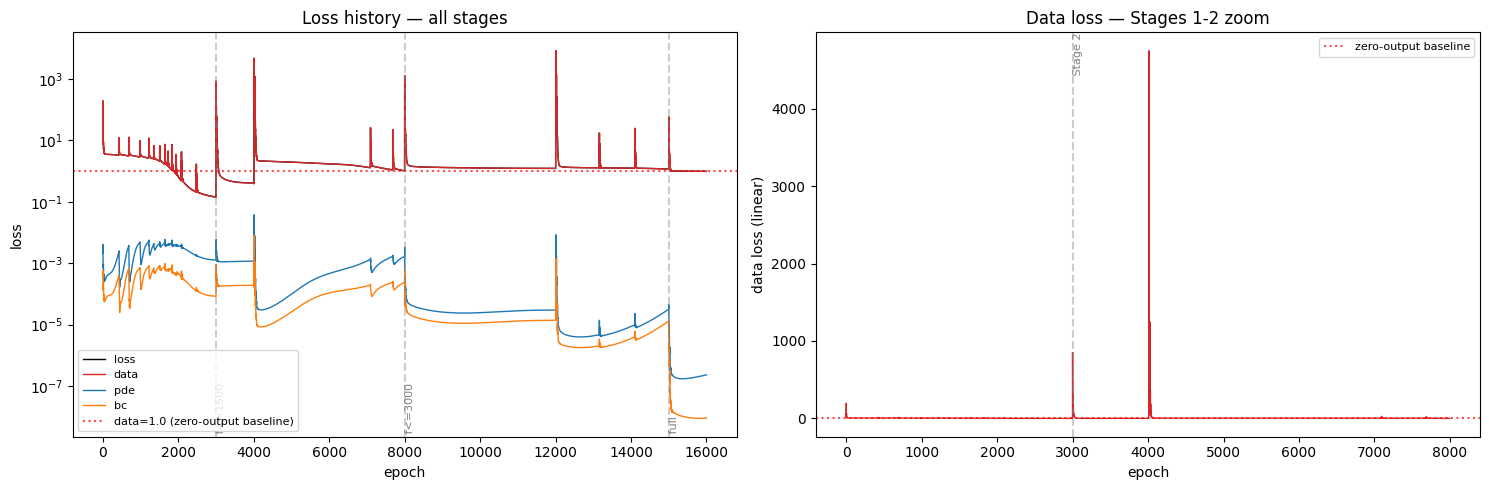


Data-loss min, Stage 1 (ep 0-3000):    0.1417
Data-loss min, Stage 2 (ep 3000-8000): 0.3884
Data-loss min, whole run:              0.1417  (at epoch 2999)


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

# Prefer the live Adam checkpoint; fall back to the final one if it exists.
ckpt_path = next((p for p in [CKPT_ADAM, CKPT_DONE] if os.path.exists(p)), None)
assert ckpt_path is not None, "No checkpoint found in Drive."

ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
hist = ckpt["history"]
data = np.array(hist["data"])
n = len(data); ep = np.arange(n)
print(f"Loaded {ckpt_path}")
print(f"History spans epoch 0 .. {n-1}   (should start at 0 — if not, early history was lost on a restart)")

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Left: all loss components, full run
for k, c in [("loss", "k"), ("data", "C3"), ("pde", "C0"), ("bc", "C1")]:
    if k in hist:
        axs[0].semilogy(ep, hist[k], label=k, color=c, lw=1)
axs[0].axhline(1.0, color="red", ls=":", alpha=0.7, label="data=1.0 (zero-output baseline)")
for x, lbl in [(3000, "f<=1500"), (8000, "f<=3000"), (15000, "full")]:
    if x < n:
        axs[0].axvline(x, color="gray", ls="--", alpha=0.4)
        axs[0].text(x, axs[0].get_ylim()[0], f" {lbl}", rotation=90, va="bottom", fontsize=8, color="gray")
axs[0].set_xlabel("epoch"); axs[0].set_ylabel("loss"); axs[0].legend(fontsize=8)
axs[0].set_title("Loss history — all stages")

# Right: data loss, Stages 1-2 zoom (linear scale, this is the question)
end = min(8000, n)
axs[1].plot(ep[:end], data[:end], color="C3", lw=1)
axs[1].axhline(1.0, color="red", ls=":", alpha=0.7, label="zero-output baseline")
if n > 3000:
    axs[1].axvline(3000, color="gray", ls="--", alpha=0.4)
    axs[1].text(3000, axs[1].get_ylim()[1], " Stage 2", rotation=90, va="top", fontsize=8, color="gray")
axs[1].set_xlabel("epoch"); axs[1].set_ylabel("data loss (linear)")
axs[1].set_title("Data loss — Stages 1-2 zoom"); axs[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

# The actual question, answered numerically:
print(f"\nData-loss min, Stage 1 (ep 0-3000):    {data[:min(3000, n)].min():.4f}")
if n > 3000:
    print(f"Data-loss min, Stage 2 (ep 3000-8000): {data[3000:min(8000, n)].min():.4f}")
print(f"Data-loss min, whole run:              {data.min():.4f}  (at epoch {int(data.argmin())})")

## 13. Training history

With v8's physical normalisation the absolute values are meaningful:

- **data**: 1.0 = predicting V ≡ 0; target 0.01–0.1 (1–10% energy mis-fit).
  Expect visible jumps at epochs 3000 / 8000 / 15000 when curriculum stages
  add new frequency bands.
- **pde / bc**: dimensionless O(1) residuals; should decrease steadily. If
  **pde stays high**, the network hasn't learned the beam equation — more
  collocation points or epochs. If **data stays low but pde is low too and the
  FRF plot is still smooth**, raise FOURIER_SIGMA (peaks may still be beyond
  the feature bandwidth).
- If **bc stays high**: boundary conditions not satisfied — check BC
  formulation or w_bc weight.
- The scalar plot is the key health check: in v7 all four scalars sat at their
  initial values. In v8 they should visibly move.


In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].semilogy(history["loss"],  label="total")
axs[0].semilogy(history["pde"],   label="pde")
axs[0].semilogy(history["bc"],    label="bc")
axs[0].semilogy(history["data"],  label="data")
axs[0].legend(); axs[0].set_title("Loss history (Adam phase)"); axs[0].set_xlabel("Epoch")

axs[1].plot(history["eta"],  label="eta")
axs[1].plot(history["kx"],   label="kx (scaled)")
axs[1].plot(history["kphi"], label="kphi (scaled)")
axs[1].plot(history["F"],    label="F")
axs[1].legend(); axs[1].set_title("Scalar parameter convergence"); axs[1].set_xlabel("Epoch")

plt.tight_layout(); plt.show()


## 14. Identified E(x) spatial profile

This is the key result — the spatially varying Young's modulus profile along the beam.
If E(x) is nearly flat, the beam has uniform stiffness.
Spatial variation indicates non-uniform material, damage, or geometric effects.

**v4 note:** E(x) is now bounded in [50, 400] GPa via sigmoid reparameterization.
In v3, E(x) blew up to 4400 GPa — clearly unphysical. The bounds prevent this.

**Sanity check:** E(x) values should be physically plausible for your material:
- Steel: 180-210 GPa
- Aluminium: 65-75 GPa
- Brass: 95-110 GPa

In [ ]:
w_net.eval(); e_net.eval()

x_plot = np.linspace(0, L, 200)
x_plot_t = torch.tensor(x_plot, dtype=DTYPE, device=device).view(-1,1)

with torch.no_grad():
    E_profile = e_net(x_plot_t).cpu().numpy().reshape(-1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_plot*1000, E_profile/1e9, "b-", lw=2)
ax.set_xlabel("Position along beam x [mm]")
ax.set_ylabel("E(x) [GPa]")
ax.set_title("Identified spatially varying Young's modulus E(x)")
ax.axhline(E0_init/1e9, color="r", linestyle="--", alpha=0.5, label=f"Initial guess {E0_init/1e9:.0f} GPa")
ax.axhline(E_MIN/1e9, color="gray", linestyle=":", alpha=0.3, label=f"Bounds [{E_MIN/1e9:.0f}, {E_MAX/1e9:.0f}] GPa")
ax.axhline(E_MAX/1e9, color="gray", linestyle=":", alpha=0.3)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"E(x) range: {E_profile.min()/1e9:.2f} - {E_profile.max()/1e9:.2f} GPa")
print(f"E(x) mean:  {E_profile.mean()/1e9:.2f} GPa")

## 15. Final identified scalar parameters


In [ ]:
eta_f, kx_f, kphi_f, F_f = get_params()

print("=== IDENTIFIED SCALAR PARAMETERS ===")
print(f"eta   = {eta_f.item():.6f}        (damping loss factor)")
print(f"kx    = {kx_f.item():.4e} N/m    (translational spring at x=0)")
print(f"kphi  = {kphi_f.item():.4e} N·m/rad (rotational spring at x=0)")
print(f"F     = {F_f.item():.6f} N       (tip force amplitude)")


## 16. PINN prediction vs experimental FRF

This is the final validation. The PINN-predicted velocity FRF should:
- Match the resonance peak **positions** closely (driven by E(x) and geometry)
- Match the peak **heights** approximately (driven by eta and F)
- Produce a smooth curve — it will not reproduce noise between peaks, and should not

If the peaks are misaligned in frequency: E(x) mean level needs adjustment (check E0_init)
If peaks are there but wrong height: check eta and F convergence
If the prediction is still a flat line: check loss history — training may not have converged


In [ ]:
omega_eval_t = omega_t.clone()
x_eval_t     = torch.full_like(omega_eval_t, x_meas, dtype=DTYPE)

with torch.no_grad():
    Wr_p, Wi_p = w_net(x_eval_t, omega_eval_t)
    Vp_r = (-omega_eval_t * Wi_p).cpu().numpy().reshape(-1)
    Vp_i = ( omega_eval_t * Wr_p).cpu().numpy().reshape(-1)
    V_pred = Vp_r + 1j*Vp_i

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axs[0].plot(f_train, 20*np.log10(np.abs(V_train) + eps_db),
            alpha=0.5, label="Experimental")
axs[0].plot(f_train, 20*np.log10(np.abs(V_pred)  + eps_db),
            "r--", lw=2, label="PINN prediction")
axs[0].set_ylabel("Magnitude [dB]"); axs[0].legend()
axs[0].set_title("PINN vs Experimental FRF")

axs[1].plot(f_train, np.unwrap(np.angle(V_train)), alpha=0.5, label="Experimental")
axs[1].plot(f_train, np.unwrap(np.angle(V_pred)),  "r--", lw=2, label="PINN prediction")
axs[1].set_ylabel("Phase [rad]"); axs[1].set_xlabel("Frequency [Hz]"); axs[1].legend()

plt.tight_layout(); plt.show()


## 17. Save results


In [ ]:
results = {
    "eta":   float(eta_f.item()),
    "kx":    float(kx_f.item()),
    "kphi":  float(kphi_f.item()),
    "F":     float(F_f.item()),
    "E_profile_x_mm":  (x_plot*1000).tolist(),
    "E_profile_GPa":   (E_profile/1e9).tolist(),
    "geometry": {"L":L,"width":width,"height":height,"rho":rho,"m_tip":m_tip},
    "freq_range_hz": [MIN_FREQ_HZ, MAX_FREQ_HZ],
}
with open("pinn_results.json","w") as f:
    json.dump(results, f, indent=2)

pd.DataFrame({
    "f_hz":        f_train,
    "V_exp_real":  V_train.real,
    "V_exp_imag":  V_train.imag,
    "V_pred_real": V_pred.real,
    "V_pred_imag": V_pred.imag,
    "V_exp_dB":    20*np.log10(np.abs(V_train)+eps_db),
    "V_pred_dB":   20*np.log10(np.abs(V_pred) +eps_db),
}).to_csv("pinn_frf_comparison.csv", index=False)

print("Saved: pinn_results.json")
print("Saved: pinn_frf_comparison.csv")

# ── Save final trained state & clean up per-phase checkpoints ────────────────
# This saves the fully trained model so you can reload it later for inference
# without retraining. The per-phase checkpoints are removed since training
# is complete — they were only needed for crash recovery.
torch.save({
    "w_net": w_net.state_dict(),
    "e_net": e_net.state_dict(),
    "phys":  {k: v.detach().clone() for k, v in phys_params.items()},
    "history": history,
}, CKPT_DONE)

# Remove intermediate checkpoints (no longer needed)
for p in [CKPT_ADAM, CKPT_LBFGS]:
    if os.path.exists(p):
        os.remove(p)

print(f"Saved final model: {CKPT_DONE}")
print("Intermediate checkpoints cleaned up.")


## 18. Utilities: fresh start / reload trained model

**To start a completely fresh training run** (e.g. new experiment file),
delete the checkpoint files first:

```python
import os
for f in [CKPT_ADAM, CKPT_LBFGS, CKPT_DONE]:
    if os.path.exists(f): os.remove(f)
print("Checkpoints cleared — next run will train from scratch.")
```

**To reload a trained model without retraining** (e.g. to make new plots):

```python
ckpt = torch.load(CKPT_DONE, map_location=device, weights_only=False)
w_net.load_state_dict(ckpt["w_net"])
e_net.load_state_dict(ckpt["e_net"])
for k, v in ckpt["phys"].items():
    phys_params[k].data.copy_(v)
print("Loaded trained model from", CKPT_DONE)
```
